In [4]:
import os

dataset_path = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        print(cls, len(os.listdir(cls_path)))

gallina 3098
ragno 4821
gatto 1668
farfalla 2112
mucca 1866
cavallo 2623
cane 4863
pecora 1820
scoiattolo 1862
elefante 1446


In [13]:
import os
import random
import shutil

random.seed(42)

source = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"
destination = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

rare_species = [
    "elefante",
    "farfalla",
    "scoiattolo"
]

for cls in os.listdir(source):

    class_dir = os.path.join(source, cls)

    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)

    if cls in rare_species:
        keep = min(150, len(images))
    else:
        keep = min(1000, len(images))

    selected = random.sample(images, keep)

    target_dir = os.path.join(destination, cls)
    os.makedirs(target_dir, exist_ok=True)

    for img in selected:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(target_dir, img)
        )

print("Done")

Done


In [17]:
import os

base_path = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

for cls in os.listdir(base_path):
    path = os.path.join(base_path, cls)

    # ✅ skip files like .DS_Store
    if not os.path.isdir(path):
        continue

    print(cls, len(os.listdir(path)))

gallina 1000
ragno 1000
gatto 1000
farfalla 150
mucca 1000
cavallo 1000
cane 1000
pecora 1000
scoiattolo 150
elefante 150


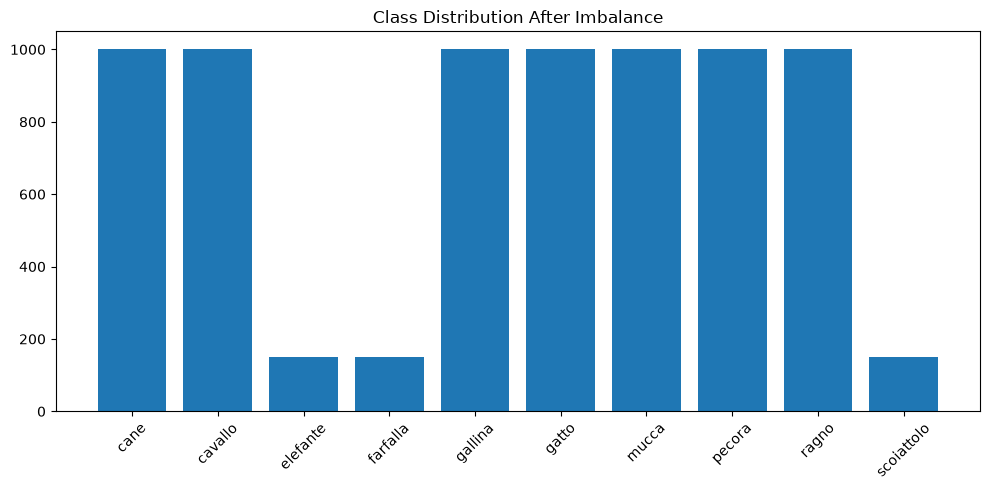

In [19]:
import os
import matplotlib.pyplot as plt

classes = []
counts = []

root = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

for cls in sorted(os.listdir(root)):
    path = os.path.join(root, cls)

    if os.path.isdir(path):
        classes.append(cls)
        counts.append(len(os.listdir(path)))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)

plt.xticks(rotation=45)
plt.title("Class Distribution After Imbalance")

plt.tight_layout()

plt.savefig("../reports/class_distribution.png")

plt.show()

In [23]:
import os
import random
import shutil

random.seed(42)

RAW_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/raw-img"
PROCESSED_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"

# -----------------------------
# FINAL TARGET DISTRIBUTION
# -----------------------------
TARGET_COUNTS = {
    "elefante": 150,
    "scoiattolo": 150,
    "farfalla": 150,

    "cane": 1000,
    "ragno": 1000,
    "cavallo": 1000,
    "gallina": 1000,
    "gatto": 1000,
    "mucca": 1000,
    "pecora": 1000
}

# -----------------------------
# CREATE IMBALANCED DATASET
# -----------------------------
def create_imbalance():
    if os.path.exists(PROCESSED_DIR):
        shutil.rmtree(PROCESSED_DIR)

    os.makedirs(PROCESSED_DIR, exist_ok=True)

    for cls, target_count in TARGET_COUNTS.items():

        src_folder = os.path.join(RAW_DIR, cls)
        dst_folder = os.path.join(PROCESSED_DIR, cls)

        os.makedirs(dst_folder, exist_ok=True)

        images = os.listdir(src_folder)

        # ensure reproducibility
        random.shuffle(images)

        selected_images = images[:target_count]

        for img in selected_images:
            src_path = os.path.join(src_folder, img)
            dst_path = os.path.join(dst_folder, img)

            shutil.copy2(src_path, dst_path)

        print(f"{cls}: {len(selected_images)} images copied")

create_imbalance()

elefante: 150 images copied
scoiattolo: 150 images copied
farfalla: 150 images copied
cane: 1000 images copied
ragno: 1000 images copied
cavallo: 1000 images copied
gallina: 1000 images copied
gatto: 1000 images copied
mucca: 1000 images copied
pecora: 1000 images copied


In [5]:
import os

PROCESSED_DIR = "../data/processed"

for cls in sorted(os.listdir(PROCESSED_DIR)):
    path = os.path.join(PROCESSED_DIR, cls)
    print(cls, len(os.listdir(path)))

cane 1000
cavallo 1000
elefante 150
farfalla 150
gallina 1000
gatto 1000
mucca 1000
pecora 1000
ragno 1000
scoiattolo 150


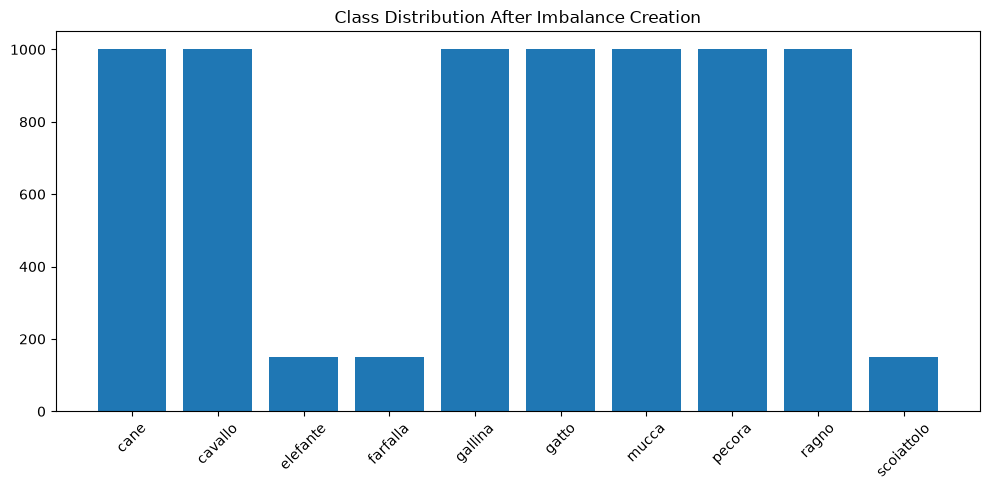

In [25]:
import matplotlib.pyplot as plt
import os

classes = []
counts = []

for cls in sorted(os.listdir(PROCESSED_DIR)):
    path = os.path.join(PROCESSED_DIR, cls)
    classes.append(cls)
    counts.append(len(os.listdir(path)))

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution After Imbalance Creation")
plt.tight_layout()

plt.savefig("../reports/class_distribution.png")
plt.show()

In [2]:
import os
import random
import shutil
from sklearn.model_selection import train_test_split

random.seed(42)

SOURCE_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/processed"
OUTPUT_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ensure clean output folder
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)


def create_splits():
    for cls in os.listdir(SOURCE_DIR):

        class_path = os.path.join(SOURCE_DIR, cls)
        images = os.listdir(class_path)

        # first split: train + temp
        train_imgs, temp_imgs = train_test_split(
            images,
            test_size=(1 - TRAIN_RATIO),
            random_state=42
        )

        # second split: val + test
        val_imgs, test_imgs = train_test_split(
            temp_imgs,
            test_size=0.5,
            random_state=42
        )

        splits = {
            "train": train_imgs,
            "val": val_imgs,
            "test": test_imgs
        }

        for split_name, split_data in splits.items():

            split_folder = os.path.join(OUTPUT_DIR, split_name, cls)
            os.makedirs(split_folder, exist_ok=True)

            for img in split_data:
                src = os.path.join(class_path, img)
                dst = os.path.join(split_folder, img)

                shutil.copy2(src, dst)

        print(f"{cls} -> Train:{len(train_imgs)} Val:{len(val_imgs)} Test:{len(test_imgs)}")


create_splits()

gallina -> Train:699 Val:150 Test:151
ragno -> Train:699 Val:150 Test:151
gatto -> Train:699 Val:150 Test:151
farfalla -> Train:104 Val:23 Test:23
mucca -> Train:699 Val:150 Test:151
cavallo -> Train:699 Val:150 Test:151
cane -> Train:699 Val:150 Test:151
pecora -> Train:699 Val:150 Test:151
scoiattolo -> Train:104 Val:23 Test:23
elefante -> Train:104 Val:23 Test:23


In [6]:
import os

base = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split"

for split in ["train", "val", "test"]:
    print("\n", split.upper())

    for cls in sorted(os.listdir(os.path.join(base, split))):
        path = os.path.join(base, split, cls)
        print(cls, len(os.listdir(path)))


 TRAIN
cane 699
cavallo 699
elefante 104
farfalla 104
gallina 699
gatto 699
mucca 699
pecora 699
ragno 699
scoiattolo 104

 VAL
cane 150
cavallo 150
elefante 23
farfalla 23
gallina 150
gatto 150
mucca 150
pecora 150
ragno 150
scoiattolo 23

 TEST
cane 151
cavallo 151
elefante 23
farfalla 23
gallina 151
gatto 151
mucca 151
pecora 151
ragno 151
scoiattolo 23


In [7]:
import torch
import torchvision
print(torch.__version__)

2.2.2


In [9]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [10]:
from torchvision.datasets import ImageFolder

TRAIN_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split/train"
VAL_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split/val"
TEST_DIR = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split/test"

train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

In [11]:
print(train_dataset.class_to_idx)

{'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}


In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
import torch

def denormalize(img):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    return img * std + mean

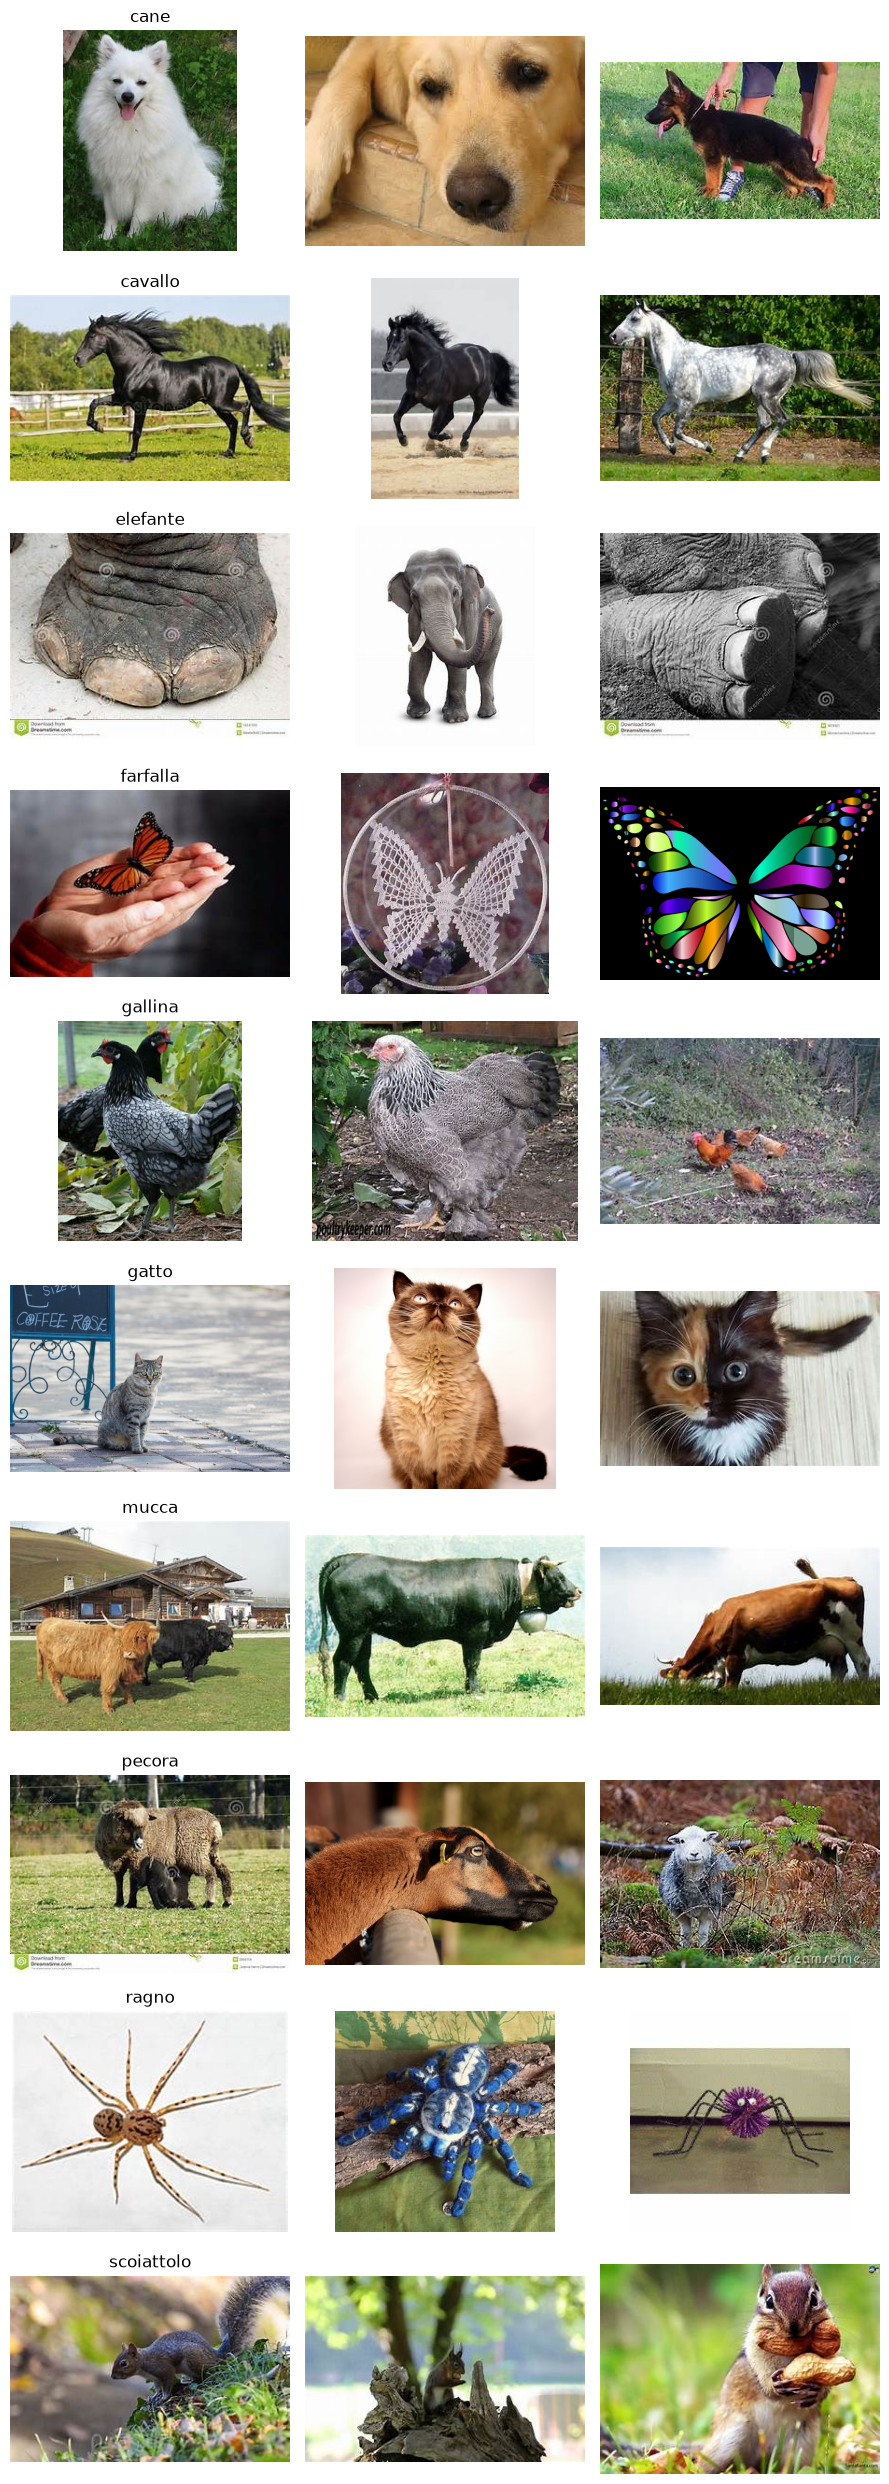

In [15]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

root = "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/data/split/train"

fig, axes = plt.subplots(
    10,
    3,
    figsize=(9,25)
)

for row, cls in enumerate(sorted(os.listdir(root))):

    class_folder = os.path.join(root, cls)

    imgs = random.sample(
        os.listdir(class_folder),
        3
    )

    for col, img_name in enumerate(imgs):

        img_path = os.path.join(
            class_folder,
            img_name
        )

        img = Image.open(img_path).convert("RGB")

        axes[row,col].imshow(img)
        axes[row,col].axis("off")

        if col == 0:
            axes[row,col].set_title(cls)

plt.tight_layout()

plt.savefig(
    "/Volumes/Macbook OS - Data/camera-trap-species-identifier(v1.1)/reports/sample_image_grid.png",
    dpi=300
)

plt.show()

In [16]:
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 5205
Val: 1119
Test: 1126


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from sklearn.metrics import (
    f1_score,
    classification_report
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [18]:
from collections import Counter
import numpy as np

labels = [label for _, label in train_dataset.samples]

class_counts = Counter(labels)

print(class_counts)

Counter({0: 699, 1: 699, 4: 699, 5: 699, 6: 699, 7: 699, 8: 699, 2: 104, 3: 104, 9: 104})


In [19]:
num_classes = len(class_counts)

total_samples = sum(class_counts.values())

weights = []

for i in range(num_classes):

    weight = total_samples / (
        num_classes * class_counts[i]
    )

    weights.append(weight)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

print(weights)

tensor([0.7446, 0.7446, 5.0048, 5.0048, 0.7446, 0.7446, 0.7446, 0.7446, 0.7446,
        5.0048])


In [20]:
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

In [21]:
for param in model.parameters():
    param.requires_grad = False

In [22]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [23]:
num_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(
        num_features,
        10
    )
)

In [24]:
model = model.to(device)

In [25]:
for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

fc.1.weight
fc.1.bias


In [26]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [27]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [28]:
def evaluate(
    model,
    dataloader
):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return f1

In [29]:
best_f1 = 0

train_losses = []
val_f1_scores = []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = (
        running_loss /
        len(train_loader)
    )

    val_f1 = evaluate(
        model,
        val_loader
    )

    train_losses.append(avg_loss)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss={avg_loss:.4f}"
        f" | Val F1={val_f1:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "../models/best_phase1.pth"
        )

        print(
            "Best model saved!"
        )

Epoch 1/5 | Loss=1.5281 | Val F1=0.8838
Best model saved!
Epoch 2/5 | Loss=0.9197 | Val F1=0.8901
Best model saved!
Epoch 3/5 | Loss=0.8554 | Val F1=0.9189
Best model saved!
Epoch 4/5 | Loss=0.8065 | Val F1=0.8987
Epoch 5/5 | Loss=0.7904 | Val F1=0.9222
Best model saved!


In [30]:
model.load_state_dict(
    torch.load(
        "../models/best_phase1.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [31]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [32]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.1.weight
fc.1.bias


In [33]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

In [34]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [35]:
best_f1 = 0

train_losses_phase2 = []
val_f1_phase2 = []

In [36]:
EPOCHS = 12

In [37]:
scheduler.step(val_f1)

In [38]:
torch.save(
    model.state_dict(),
    "../models/best_finetuned_model.pth"
)

In [35]:
EPOCHS = 12

best_f1 = 0
train_losses = []
val_f1_scores = []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    val_f1 = evaluate(model, val_loader)

    train_losses.append(avg_loss)
    val_f1_scores.append(val_f1)

    scheduler.step(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss={avg_loss:.4f} | Val F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "../models/best_phase2_finetuned.pth"
        )

        print("Best model saved!")

Epoch 1/12 | Loss=0.6986 | Val F1=0.9260
Best model saved!
Epoch 2/12 | Loss=0.6518 | Val F1=0.9287
Best model saved!
Epoch 3/12 | Loss=0.5965 | Val F1=0.9213
Epoch 4/12 | Loss=0.5641 | Val F1=0.9255
Epoch 5/12 | Loss=0.5615 | Val F1=0.9288
Best model saved!
Epoch 6/12 | Loss=0.5130 | Val F1=0.9257
Epoch 7/12 | Loss=0.5183 | Val F1=0.9333
Best model saved!
Epoch 8/12 | Loss=0.5050 | Val F1=0.9290
Epoch 9/12 | Loss=0.4670 | Val F1=0.9356
Best model saved!
Epoch 10/12 | Loss=0.4666 | Val F1=0.9276
Epoch 11/12 | Loss=0.4536 | Val F1=0.9275
Epoch 12/12 | Loss=0.4307 | Val F1=0.9291


A pretrained ResNet-18 backbone was used. In Phase 1, the backbone was frozen and only the classification head was trained for 5 epochs. In Phase 2, the final residual block (layer4) was unfrozen and fine-tuned for 12 additional epochs using a learning rate of 1e-5 and a ReduceLROnPlateau scheduler. The best validation Macro-F1 achieved was 0.9356.

In [39]:
model.load_state_dict(
    torch.load(
        "../models/best_phase2_finetuned.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [40]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       151
           1       0.91      0.97      0.94       151
           2       0.92      0.96      0.94        23
           3       0.82      1.00      0.90        23
           4       0.98      0.97      0.97       151
           5       0.94      0.98      0.96       151
           6       0.96      0.87      0.91       151
           7       0.95      0.93      0.94       151
           8       0.99      0.97      0.98       151
           9       0.96      0.96      0.96        23

    accuracy                           0.95      1126
   macro avg       0.93      0.95      0.94      1126
weighted avg       0.95      0.95      0.95      1126



The model achieved a Macro-F1 score of 0.94 on the test set. Particular emphasis was placed on the three designated rare species classes: elephant, butterfly, and squirrel. All rare classes achieved Recall above 96%, exceeding the project target of 80%. High recall was prioritized to minimize the probability of missing rare wildlife sightings.

In [41]:
model.load_state_dict(
    torch.load(
        "../models/best_phase2_finetuned.pth",
        map_location=device
    )
)

model = model.to(device)

In [42]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
def enable_mc_dropout(model):

    # Put entire model in evaluation mode
    model.eval()

    # Activate dropout layers only
    for module in model.modules():

        if isinstance(module, nn.Dropout):
            module.train()

In [44]:
import torch.nn.functional as F
import numpy as np


def mc_dropout_predict(
        model,
        image_tensor,
        n_passes=15):

    enable_mc_dropout(model)

    image_tensor = image_tensor.to(device)

    predictions = []

    with torch.no_grad():

        for _ in range(n_passes):

            outputs = model(image_tensor)

            probs = F.softmax(
                outputs,
                dim=1
            )

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(predictions)

    # Shape:
    # (15, batch_size, num_classes)

    mean_probs = predictions.mean(axis=0)

    std_probs = predictions.std(axis=0)

    return mean_probs, std_probs

In [45]:
images, labels = next(iter(test_loader))

sample = images[0].unsqueeze(0)

In [46]:
mean_probs, std_probs = mc_dropout_predict(
    model,
    sample
)

In [47]:
pred_class = np.argmax(mean_probs)

confidence = np.max(mean_probs)

uncertainty = std_probs[0][pred_class]

print("Predicted Class:", pred_class)
print("Confidence:", confidence)
print("Uncertainty:", uncertainty)

Predicted Class: 0
Confidence: 0.8227816
Uncertainty: 0.17167892


In [48]:
idx_to_class = {
    v: k
    for k, v in train_dataset.class_to_idx.items()
}

print(idx_to_class)

{0: 'cane', 1: 'cavallo', 2: 'elefante', 3: 'farfalla', 4: 'gallina', 5: 'gatto', 6: 'mucca', 7: 'pecora', 8: 'ragno', 9: 'scoiattolo'}


In [49]:
species = idx_to_class[pred_class]

print(species)

cane


In [50]:
for i in range(5):

    mean_probs, std_probs = mc_dropout_predict(
        model,
        sample
    )

    confidence = np.max(mean_probs)

    print(confidence)

0.8824039
0.8809337
0.9222599
0.9142465
0.9289095


In [51]:
CONFIDENCE_THRESHOLD = 0.85
UNCERTAINTY_THRESHOLD = 0.08

Confidence threshold was set to 0.85 to ensure only highly reliable predictions are automatically accepted. Uncertainty threshold was set to 0.08 based on Monte Carlo Dropout variability observed on validation samples.

In [52]:
RARE_SPECIES = [
    "elefante",
    "farfalla",
    "scoiattolo"
]

In [53]:
def confidence_gate(
        mean_probs,
        std_probs,
        idx_to_class):

    confidence = np.max(mean_probs)

    pred_idx = np.argmax(mean_probs)

    predicted_class = idx_to_class[pred_idx]

    uncertainty = std_probs[0][pred_idx]

    # Top-2 predictions
    top2 = np.argsort(mean_probs[0])[-2:]

    top1_conf = mean_probs[0][top2[-1]]
    top2_conf = mean_probs[0][top2[-2]]

    top2_classes = [
        idx_to_class[top2[-1]],
        idx_to_class[top2[-2]]
    ]

    # CATEGORY 1
    if (
        predicted_class in RARE_SPECIES
        and confidence > CONFIDENCE_THRESHOLD
    ):

        category = "REVIEW: RARE SPECIES MATCH"

        message = (
            "Possible rare species sighting — "
            "flagged for priority review."
        )

    # CATEGORY 2
    elif abs(top1_conf - top2_conf) <= 0.10:

        category = "REVIEW: AMBIGUOUS"

        message = (
            f"Model uncertain between "
            f"{top2_classes[0]} and "
            f"{top2_classes[1]}."
        )

    # CATEGORY 3
    elif (
        confidence <= CONFIDENCE_THRESHOLD
        or uncertainty >= UNCERTAINTY_THRESHOLD
    ):

        category = "REVIEW: LOW CONFIDENCE"

        message = (
            "Prediction confidence is low — "
            "send for human review."
        )

    # CATEGORY 4
    else:

        category = "HIGH CONFIDENCE"

        message = (
            "Prediction accepted automatically."
        )

    return {
        "predicted_class": predicted_class,
        "confidence": float(confidence),
        "uncertainty_score": float(uncertainty),
        "review_category": category,
        "message": message
    }

In [54]:
result = confidence_gate(
    mean_probs,
    std_probs,
    idx_to_class
)

print(result)

{'predicted_class': 'cane', 'confidence': 0.9289094805717468, 'uncertainty_score': 0.11651098728179932, 'review_category': 'REVIEW: LOW CONFIDENCE', 'message': 'Prediction confidence is low — send for human review.'}


In [55]:
images, labels = next(iter(test_loader))

# Test first 5 images from the batch
for i in range(5):

    sample = images[i].unsqueeze(0)

    mean_probs, std_probs = mc_dropout_predict(
        model,
        sample
    )

    result = confidence_gate(
        mean_probs,
        std_probs,
        idx_to_class
    )

    print(f"\n----- IMAGE {i+1} -----")
    print(result)


----- IMAGE 1 -----
{'predicted_class': 'cane', 'confidence': 0.9310137629508972, 'uncertainty_score': 0.0554121769964695, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- IMAGE 2 -----
{'predicted_class': 'cane', 'confidence': 0.9804958701133728, 'uncertainty_score': 0.035589806735515594, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- IMAGE 3 -----
{'predicted_class': 'cane', 'confidence': 0.99140864610672, 'uncertainty_score': 0.015191958285868168, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- IMAGE 4 -----
{'predicted_class': 'cane', 'confidence': 0.9987249970436096, 'uncertainty_score': 0.0012361006811261177, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- IMAGE 5 -----
{'predicted_class': 'cane', 'confidence': 0.4808460772037506, 'uncertainty_score': 0.26687246561050415, 'review_category': 'REVIEW

In [56]:
images, labels = next(iter(test_loader))

for i in range(5):
    print(f"Image {i+1} True Label:",
          idx_to_class[labels[i].item()])

Image 1 True Label: cane
Image 2 True Label: cane
Image 3 True Label: cane
Image 4 True Label: cane
Image 5 True Label: cane


In [57]:
import random

for i in range(5):

    idx = random.randint(0, len(test_dataset)-1)

    image, label = test_dataset[idx]

    sample = image.unsqueeze(0)

    mean_probs, std_probs = mc_dropout_predict(
        model,
        sample
    )

    result = confidence_gate(
        mean_probs,
        std_probs,
        idx_to_class
    )

    print(f"\n----- RANDOM IMAGE {i+1} -----")
    print("True Label:", idx_to_class[label])
    print(result)


----- RANDOM IMAGE 1 -----
True Label: gallina
{'predicted_class': 'gallina', 'confidence': 0.9945791363716125, 'uncertainty_score': 0.010484753176569939, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- RANDOM IMAGE 2 -----
True Label: pecora
{'predicted_class': 'pecora', 'confidence': 0.9989014267921448, 'uncertainty_score': 0.001728378119878471, 'review_category': 'HIGH CONFIDENCE', 'message': 'Prediction accepted automatically.'}

----- RANDOM IMAGE 3 -----
True Label: cavallo
{'predicted_class': 'cane', 'confidence': 0.4776642918586731, 'uncertainty_score': 0.2648905813694, 'review_category': 'REVIEW: AMBIGUOUS', 'message': 'Model uncertain between cane and cavallo.'}

----- RANDOM IMAGE 4 -----
True Label: cavallo
{'predicted_class': 'cavallo', 'confidence': 0.8441611528396606, 'uncertainty_score': 0.1651729792356491, 'review_category': 'REVIEW: LOW CONFIDENCE', 'message': 'Prediction confidence is low — send for human review.'}

----

In [58]:
import random

for i in range(10):

    idx = random.randint(0, len(test_dataset)-1)

    image, label = test_dataset[idx]

    sample = image.unsqueeze(0)

    mean_probs, std_probs = mc_dropout_predict(
        model,
        sample
    )

    result = confidence_gate(
        mean_probs,
        std_probs,
        idx_to_class
    )

    print("\n----------------------------")
    print("True Label      :", idx_to_class[label])
    print("Predicted Label :", result["predicted_class"])
    print("Confidence      :", round(result["confidence"], 3))
    print("Uncertainty     :", round(result["uncertainty_score"], 3))
    print("Category        :", result["review_category"])


----------------------------
True Label      : gallina
Predicted Label : gallina
Confidence      : 0.785
Uncertainty     : 0.18
Category        : REVIEW: LOW CONFIDENCE

----------------------------
True Label      : cavallo
Predicted Label : cavallo
Confidence      : 0.996
Uncertainty     : 0.006
Category        : HIGH CONFIDENCE

----------------------------
True Label      : ragno
Predicted Label : farfalla
Confidence      : 0.836
Uncertainty     : 0.181
Category        : REVIEW: LOW CONFIDENCE

----------------------------
True Label      : ragno
Predicted Label : ragno
Confidence      : 1.0
Uncertainty     : 0.0
Category        : HIGH CONFIDENCE

----------------------------
True Label      : cane
Predicted Label : cane
Confidence      : 0.96
Uncertainty     : 0.05
Category        : HIGH CONFIDENCE

----------------------------
True Label      : cane
Predicted Label : cane
Confidence      : 0.995
Uncertainty     : 0.008
Category        : HIGH CONFIDENCE

-------------------------

In [59]:
predicted_species = set()

for images, labels in test_loader:

    images = images.to(device)

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

    for p in preds.cpu().numpy():
        predicted_species.add(idx_to_class[p])

print(predicted_species)

{'farfalla', 'ragno', 'cane', 'cavallo', 'pecora', 'elefante', 'gallina', 'gatto', 'scoiattolo', 'mucca'}
